<a href="https://colab.research.google.com/github/JihoonJung2/undergrad-research-practicum/blob/main/day1-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from google.colab import drive
drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

classes = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cuda


100%|██████████| 170M/170M [43:09<00:00, 65.8kB/s]


In [2]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = SmallCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [3]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return total_loss/total, correct/total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    return total_loss/total, correct/total

In [4]:
EPOCHS = 20
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, trainloader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, testloader, criterion)
    scheduler.step()
    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss {train_loss:.3f} acc {train_acc:.3f} | val_loss {val_loss:.3f} acc {val_acc:.3f}")

Epoch 1/20 | train_loss 1.499 acc 0.445 | val_loss 1.268 acc 0.555
Epoch 2/20 | train_loss 1.081 acc 0.614 | val_loss 0.919 acc 0.673
Epoch 3/20 | train_loss 0.910 acc 0.678 | val_loss 0.941 acc 0.675
Epoch 4/20 | train_loss 0.820 acc 0.711 | val_loss 0.710 acc 0.749
Epoch 5/20 | train_loss 0.753 acc 0.737 | val_loss 0.715 acc 0.750
Epoch 6/20 | train_loss 0.700 acc 0.759 | val_loss 0.613 acc 0.789
Epoch 7/20 | train_loss 0.659 acc 0.771 | val_loss 0.600 acc 0.791
Epoch 8/20 | train_loss 0.622 acc 0.785 | val_loss 0.664 acc 0.776
Epoch 9/20 | train_loss 0.587 acc 0.799 | val_loss 0.605 acc 0.789
Epoch 10/20 | train_loss 0.562 acc 0.805 | val_loss 0.515 acc 0.822
Epoch 11/20 | train_loss 0.540 acc 0.813 | val_loss 0.509 acc 0.825
Epoch 12/20 | train_loss 0.507 acc 0.826 | val_loss 0.494 acc 0.824
Epoch 13/20 | train_loss 0.485 acc 0.835 | val_loss 0.472 acc 0.836
Epoch 14/20 | train_loss 0.468 acc 0.840 | val_loss 0.459 acc 0.839
Epoch 15/20 | train_loss 0.450 acc 0.848 | val_loss 0.463

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


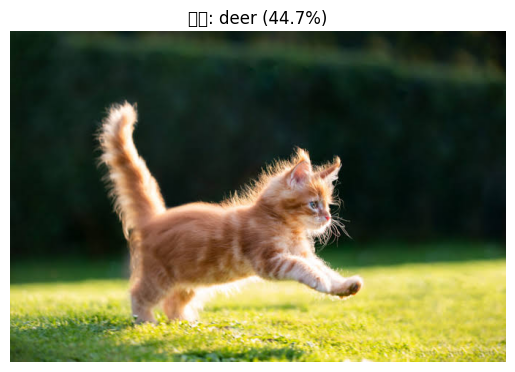

상위 3개 예측:
  deer: 44.7%
  bird: 37.9%
  dog: 8.4%


In [5]:
from PIL import Image
import matplotlib.pyplot as plt

# ↓↓↓ 여기에 구글 드라이브 이미지 경로만 바꿔서 넣으면 됨
img_path = "/content/drive/MyDrive/Lab 01 Image/cat.jpeg"

# 전처리 (학습 때 정규화값과 동일하게, augmentation은 제외)
predict_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
])

img = Image.open(img_path).convert('RGB')
img_tensor = predict_transform(img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(img_tensor)
    probs = torch.softmax(output, dim=1)[0]
    pred_idx = probs.argmax().item()

plt.imshow(img)
plt.axis('off')
plt.title(f"예측: {classes[pred_idx]} ({probs[pred_idx]*100:.1f}%)")
plt.show()

top3 = torch.topk(probs, 3)
print("상위 3개 예측:")
for i in range(3):
    print(f"  {classes[top3.indices[i]]}: {top3.values[i]*100:.1f}%")

/tmp/ipykernel_1422/1629367979.py:69: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1422/1629367979.py:69: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1422/1629367979.py:69: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1422/1629367979.py:69: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1422/1629367979.py:69: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1422/1629367979.py:69: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1422/1629367979.py:69: UserWarning: Glyph 47605 (\N{HANGUL SYLLABLE MAEB}) missing from font(s) DejaVu Sans.
  plt.tight_

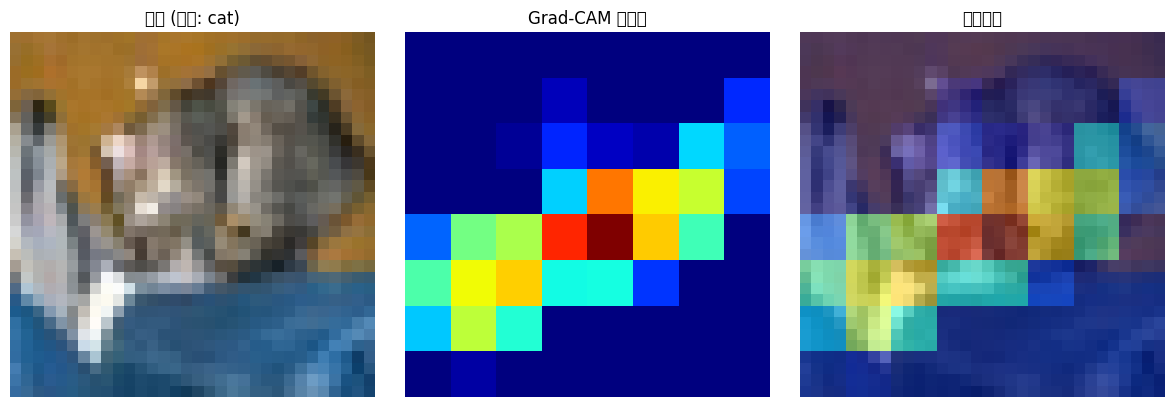

In [10]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        # forward/backward 시점에 자동으로 값을 잡아채는 hook 등록
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()   # 마지막 conv의 feature map 저장

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()   # 그 feature map에 대한 gradient 저장

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)          # forward pass

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()   # 예측 클래스 자동 선택

        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()   # 이 클래스 점수 기준으로 backward → save_gradient 자동 호출됨

        gradients = self.gradients[0]        # (채널, H, W)
        activations = self.activations[0]    # (채널, H, W)

        weights = gradients.mean(dim=(1, 2))   # 채널별 gradient 평균 = 그 채널의 중요도
        cam = torch.zeros(activations.shape[1:], dtype=torch.float32, device=activations.device)
        for i, w in enumerate(weights):
            cam += w * activations[i]           # 중요도로 가중합

        cam = F.relu(cam)   # 음수는 0으로 (클래스에 긍정적으로 기여한 부분만 보고 싶음)
        cam = cam / (cam.max() + 1e-8)   # 0~1로 정규화
        return cam.cpu().numpy(), class_idx


# ---- 사용 예시 ----
# SmallCNN의 마지막 conv 레이어를 target으로 지정 (self.features의 마지막 Conv2d)
target_layer = model.features[-3]   # MaxPool 직전의 마지막 Conv2d (구조에 따라 인덱스 확인 필요)

gradcam = GradCAM(model, target_layer)

# 테스트 이미지 하나 가져오기
images, labels = next(iter(testloader))
img_tensor = images[0:1].to(device)

cam, predicted_class = gradcam.generate(img_tensor)

# 시각화
img_display = images[0].permute(1, 2, 0).numpy()
img_display = (img_display * [0.247, 0.243, 0.261] + [0.4914, 0.4822, 0.4465]).clip(0, 1)

cam_resized = np.array(plt.cm.jet(cam / cam.max())[:, :, :3])  # 히트맵 컬러 적용
cam_resized = np.kron(cam, np.ones((32 // cam.shape[0], 32 // cam.shape[1])))  # 원본 크기로 확대

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_display); axes[0].set_title(f"원본 (예측: {classes[predicted_class]})"); axes[0].axis('off')
axes[1].imshow(cam_resized, cmap='jet'); axes[1].set_title("Grad-CAM 히트맵"); axes[1].axis('off')
axes[2].imshow(img_display); axes[2].imshow(cam_resized, cmap='jet', alpha=0.5); axes[2].set_title("오버레이"); axes[2].axis('off')
plt.tight_layout()
plt.show()